/tmp/ipykernel_2920/2882935228.py:54: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(False)
/opt/hostedtoolcache/Python/3.12.13/x64/lib/python3.12/site-packages/alphalens/utils.py:308: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = prices.pct_change(period)
/opt/hostedtoolcache/Python/3.12.13/x64/lib/python3.12/site-packages/alphalens/utils.py:308: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_m

Dropped 90.9% entries from factor data: 0.5% in forward returns computation and 90.4% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 100.0%, not exceeded: OK!
Quantiles Statistics


,min,max,mean,std,count,count %
factor_quantile,,,,,,
1.0,0.000000,0.666667,0.118933,0.124111,2294,28.219953
2.0,0.023810,0.666667,0.281715,0.150536,1655,20.359208
3.0,0.047619,0.833333,0.430091,0.201282,1645,20.236191
4.0,0.071429,0.833333,0.537857,0.258395,1317,16.201255
5.0,0.095238,1.000000,0.733697,0.294671,1218,14.983393


Returns Analysis


,1D,5D,10D
Ann. alpha,0.299,0.257,0.281
beta,-0.025,-0.054,0.015
Mean Period Wise Return Top Quantile (bps),30.877,20.229,18.356
Mean Period Wise Return Bottom Quantile (bps),-12.527,-9.170,-10.638
Mean Period Wise Spread (bps),43.405,28.419,27.691


<Figure size 640x480 with 0 Axes>

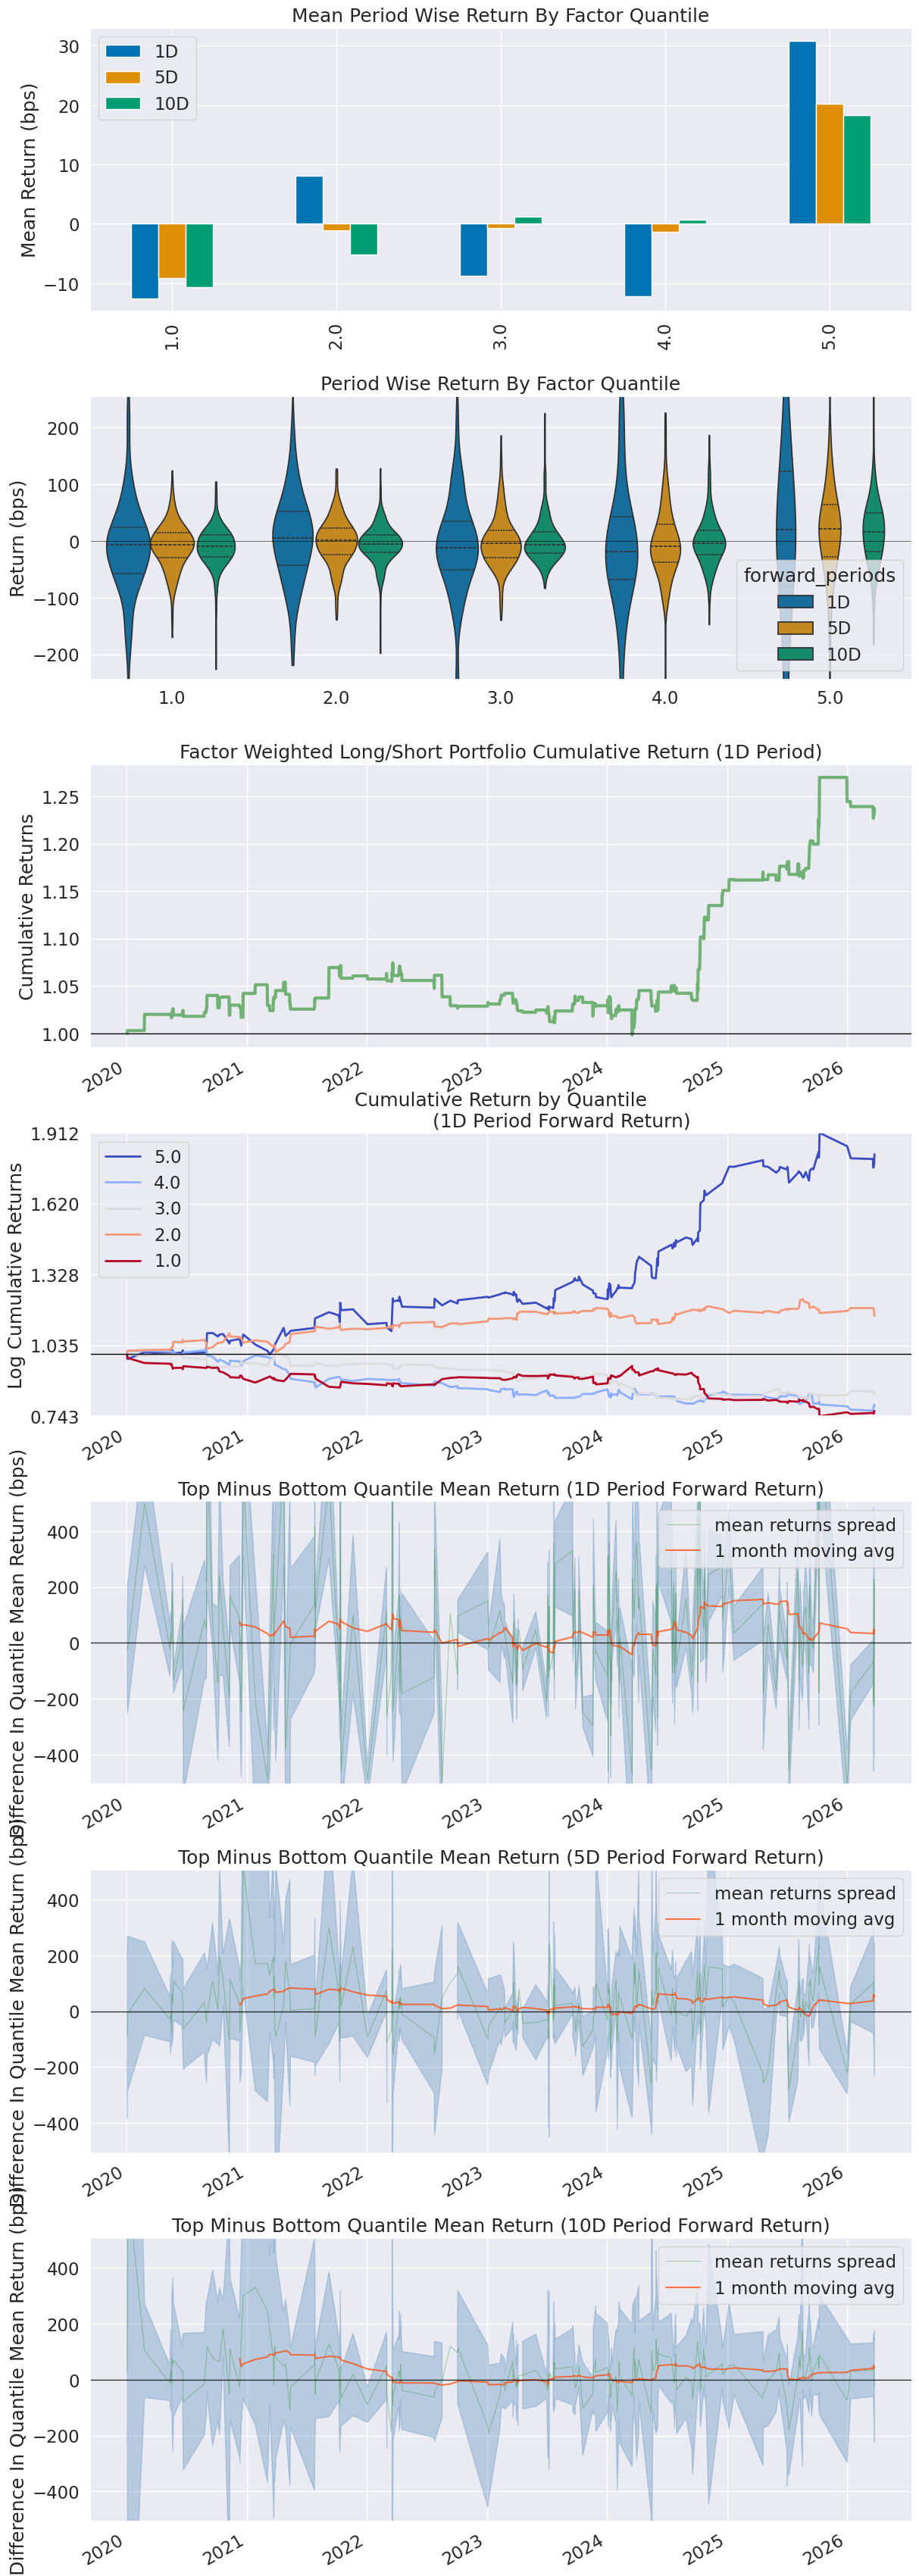

Information Analysis


,1D,5D,10D
IC Mean,-0.019,0.014,0.047
IC Std.,0.218,0.214,0.210
Risk-Adjusted IC,-0.085,0.067,0.225
t-stat(IC),NaN,NaN,NaN
p-value(IC),NaN,NaN,NaN
IC Skew,NaN,NaN,NaN
IC Kurtosis,NaN,NaN,NaN


/opt/hostedtoolcache/Python/3.12.13/x64/lib/python3.12/site-packages/alphalens/performance.py:118: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  grouper.append(pd.Grouper(freq=by_time))


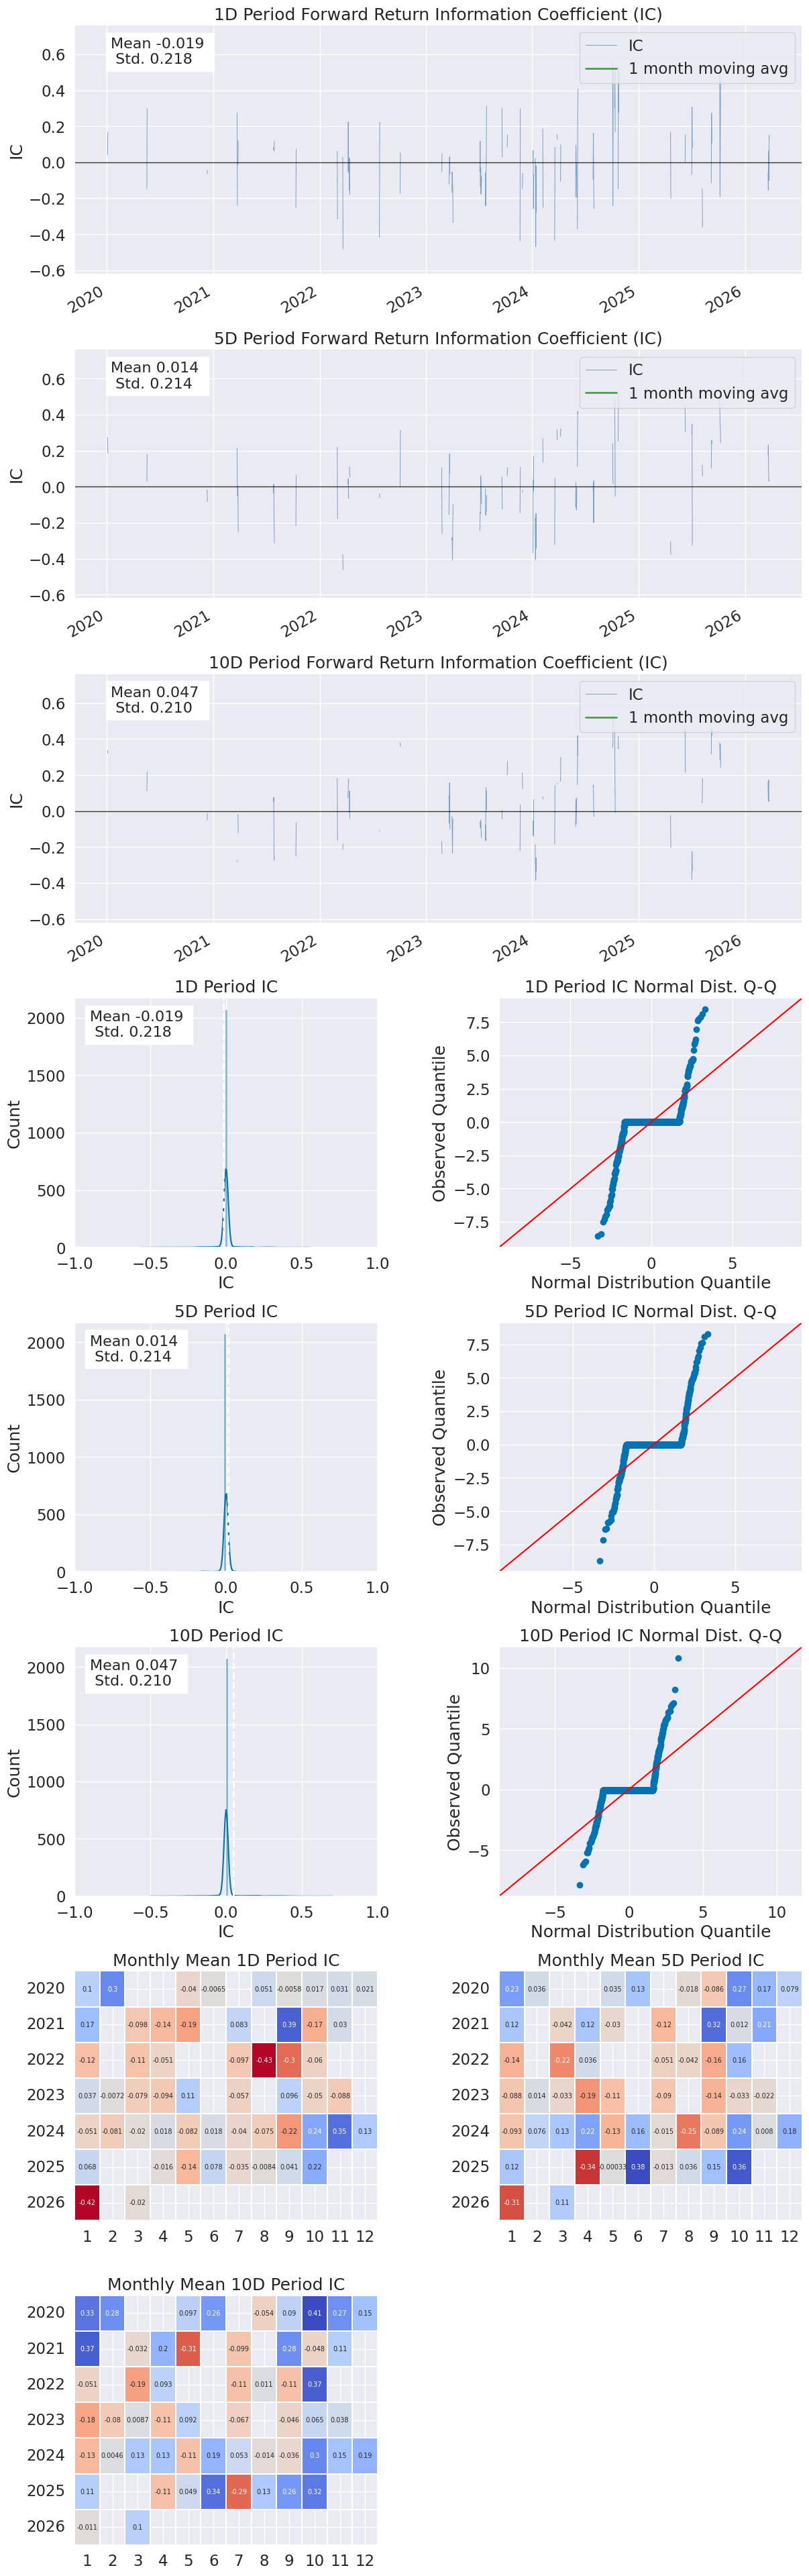

/opt/hostedtoolcache/Python/3.12.13/x64/lib/python3.12/site-packages/alphalens/utils.py:928: UserWarning: Skipping return periods that aren't exact multiples of days.
  warnings.warn(


Turnover Analysis


,1D,5D,10D
Quantile 1.0 Mean Turnover,0.213,0.328,0.486
Quantile 2.0 Mean Turnover,0.509,0.591,0.705
Quantile 3.0 Mean Turnover,0.537,0.647,0.673
Quantile 4.0 Mean Turnover,0.423,0.664,0.808
Quantile 5.0 Mean Turnover,0.229,0.483,0.533


,1D,5D,10D
Mean Factor Rank Autocorrelation,0.871,0.717,0.56


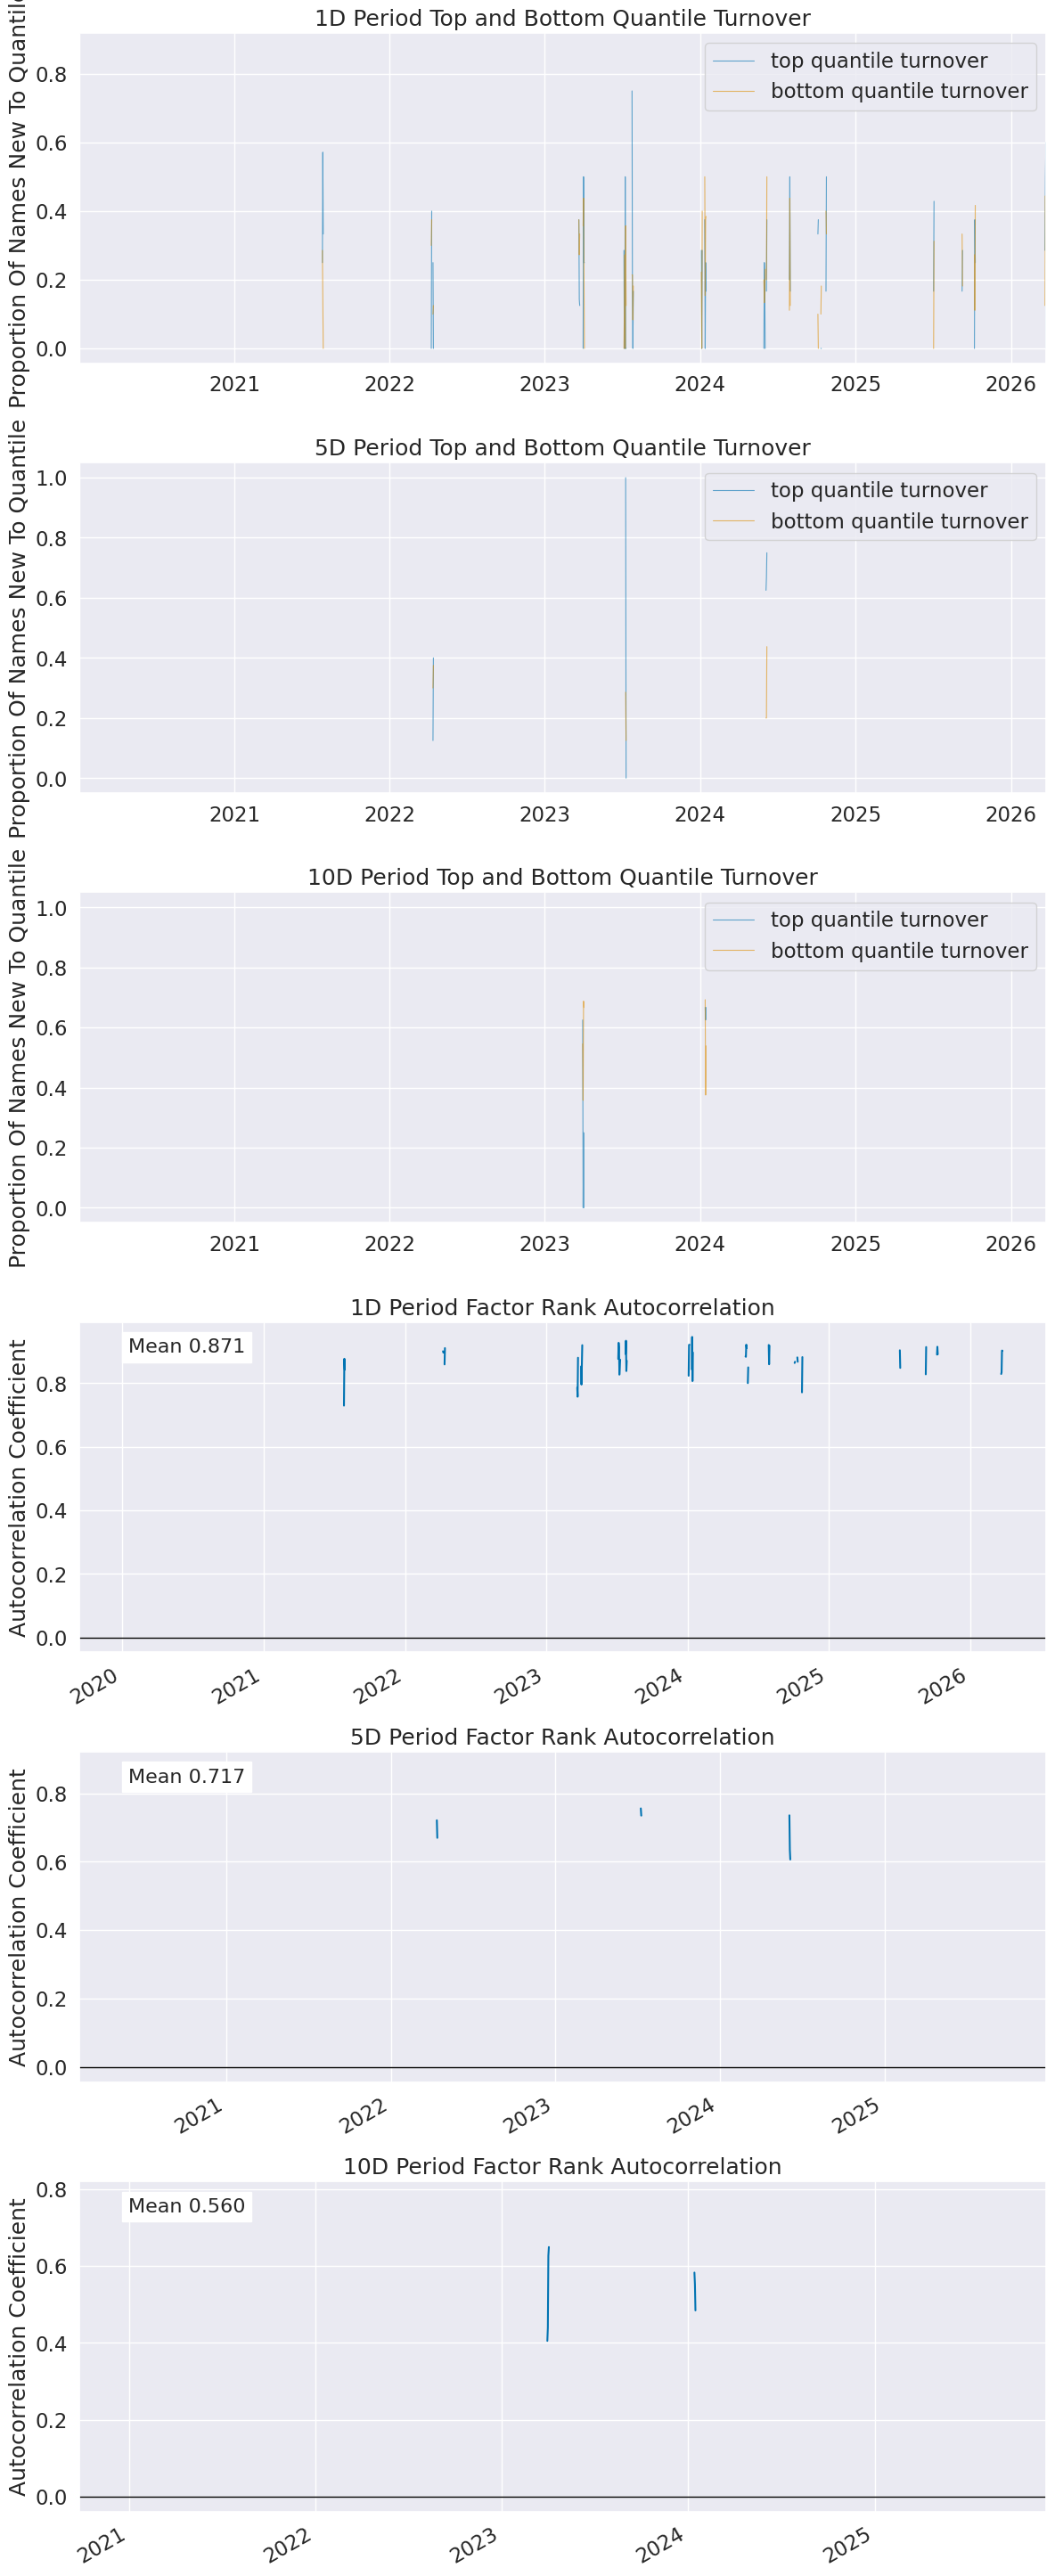

In [1]:
# AUTO-GENERATED by scripts/generate_factor_notebooks.py from
# factsheet-content/factors.yaml -- do not edit by hand. Re-run the
# generator (or the "Generate Notebooks" workflow) to refresh.
import sys
from pathlib import Path

_repo_root = Path.cwd()
while not (_repo_root / "analysis").is_dir() and _repo_root != _repo_root.parent:
    _repo_root = _repo_root.parent
sys.path.insert(0, str(_repo_root))

from unravel_client import (
    get_historical_universe,
    get_portfolio_factors_historical,
    get_prices,
    get_tickers,
)

from analysis.alphalens import factor_analysis
from analysis.utils import get_env

UNRAVEL_API_KEY = get_env("UNRAVEL_API_KEY")

# Trend Consensus Adaptive (Long-Only) -- portfolio trend_longonly_adaptive.40
portfolio = "trend_longonly_adaptive"
universe_size = "40"

available_tickers = get_tickers(
    id=portfolio,
    api_key=UNRAVEL_API_KEY,
    universe_size=universe_size,
    exchange=None,
)
historical_factors = get_portfolio_factors_historical(
    id=portfolio, tickers=available_tickers, api_key=UNRAVEL_API_KEY
)
underlying = get_prices(tickers=available_tickers, api_key=UNRAVEL_API_KEY)

# Restrict the analysis to the *dynamic* point-in-time universe rather than
# every ticker that was ever tradeable. get_historical_universe returns a
# boolean membership matrix (dates x tickers); masking the raw factor with it
# drops each asset on the days it was out of universe, so AlphaLens scores
# the factor on the universe we actually trade.
universe = get_historical_universe(
    size=universe_size,
    api_key=UNRAVEL_API_KEY,
    start_date=str(historical_factors.index.min().date()),
    end_date=str(historical_factors.index.max().date()),
)
membership = (
    universe.reindex(index=historical_factors.index)
    .ffill()
    .reindex(columns=historical_factors.columns)
    .fillna(False)
    .astype(bool)
)
restricted_factors = historical_factors.where(membership)

columns_intersection = restricted_factors.columns.intersection(underlying.columns)
factor_analysis(restricted_factors[columns_intersection], underlying)